# Training and fine tuning

In [13]:
import optuna
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

### baseline model

In [14]:
#load csv
df = pd.read_csv('../data/processed/processed_data.csv')

In [15]:
df_base = df.sort_values(by=['resto_name'])

In [16]:
# Using shift(1) is absolutely necessary to prevent data leakage
# (it ensures we only use the *past* 7 days to predict *today*)
baseline_cols = ['breakfast', 'launch', 'dinner']
baseline_pred_cols = [f"{col}_baseline_7d_avg" for col in baseline_cols]

df_base[baseline_pred_cols] = (
    df_base.groupby('resto_name')[baseline_cols]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
)

In [17]:
split_index = int(len(df_base) * 0.8)
test_df = df_base.iloc[split_index:].copy()

In [18]:
#Drop rows where the baseline is NaN 
test_clean = test_df.dropna(subset=baseline_pred_cols + baseline_cols)

In [19]:
mae_baseline = {}
rmse_baseline = {}

for col, pred_col in zip(baseline_cols, baseline_pred_cols):
    mae_baseline[col] = mean_absolute_error(test_clean[col], test_clean[pred_col])
    rmse_baseline[col] = np.sqrt(mean_squared_error(test_clean[col], test_clean[pred_col]))

In [20]:
print("--- 7-Day Moving Average Baseline ---")
for col in baseline_cols:
    print(f"{col.title()} MAE:  {mae_baseline[col]:.2f} meals")
    print(f"{col.title()} RMSE: {rmse_baseline[col]:.2f} meals")

--- 7-Day Moving Average Baseline ---
Breakfast MAE:  0.75 meals
Breakfast RMSE: 1.28 meals
Launch MAE:  0.50 meals
Launch RMSE: 0.90 meals
Dinner MAE:  0.50 meals
Dinner RMSE: 0.89 meals


### Catboost

In [21]:
target_cols = ['breakfast', 'launch', 'dinner']
X = df.drop(columns=target_cols)
y = df[target_cols]

In [22]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [23]:
categorical_features = ['resto_name',]

In [24]:
from catboost import CatBoostRegressor
from catboost.utils import get_gpu_device_count
import numpy as np
import pandas as pd


class CanteenMealRegressor:
    """
    A custom regressor that wraps three separate CatBoostRegressor models
    for breakfast, launch (lunch), and dinner.

    It automatically filters out lag features of other meals, drops constant/zero
    columns in the training set for each target, and routes prediction requests
    to the correct model.
    """

    def __init__(self, catboost_params=None):
        self.catboost_params = catboost_params or {}
        self.targets = ["breakfast", "launch", "dinner"]
        self.models = {}
        self.feature_cols = {}
        self.dropped_cols = {}

        # Configure GPU/CPU fallback
        if "task_type" not in self.catboost_params:
            try:
                gpu_count = get_gpu_device_count()
                if gpu_count > 0:
                    self.catboost_params["task_type"] = "GPU"
                else:
                    self.catboost_params["task_type"] = "CPU"
            except Exception:
                self.catboost_params["task_type"] = "CPU"

    def _get_target_features(self, X, target, is_training=True):
        """
        Helper to filter features for a specific target by dropping other targets
        and other targets' lag features.
        """
        # Ensure we don't modify the original DataFrame
        X_target = X.copy()

        # Drop all target columns if they are present in features
        for t in self.targets:
            if t in X_target.columns:
                X_target = X_target.drop(columns=[t])

        # Lag columns to drop (all lag columns except for the target's lag columns)
        other_targets = [t for t in self.targets if t != target]
        lag_cols_to_drop = []
        for ot in other_targets:
            lag_cols_to_drop.extend([f"{ot}_last_day", f"{ot}_last_week", f"{ot}_avg_previous"])

        # Drop lag columns of other targets if they exist in X
        lag_cols_to_drop = [c for c in lag_cols_to_drop if c in X_target.columns]
        if lag_cols_to_drop:
            X_target = X_target.drop(columns=lag_cols_to_drop)

        if is_training:
            # Drop zero or constant columns (columns with all 0s or <= 1 unique value)
            dropped = []
            for col in X_target.columns:
                if (X_target[col] == 0).all() or X_target[col].nunique() <= 1:
                    dropped.append(col)

            if dropped:
                X_target = X_target.drop(columns=dropped)

            self.dropped_cols[target] = dropped
            self.feature_cols[target] = X_target.columns.tolist()
        else:
            # Keep only the features that were used during training
            active_cols = self.feature_cols.get(target, X_target.columns.tolist())
            # Ensure we only select features that exist
            active_cols = [c for c in active_cols if c in X_target.columns]
            X_target = X_target[active_cols]

        return X_target

    def fit(self, X, y):
        """
        Fits 3 separate models on X and y.
        y should be a pandas DataFrame or 2D array containing the columns
        'breakfast', 'launch', and 'dinner'.
        """
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not isinstance(y, pd.DataFrame):
            y = pd.DataFrame(y, columns=self.targets)

        for target in self.targets:
            print(f"Training model for target: {target}...")
            # Get target-specific features
            X_target = self._get_target_features(X, target, is_training=True)
            y_target = y[target]

            # Identify categorical features dynamically
            cat_features = X_target.select_dtypes(include=["object", "category"]).columns.tolist()

            # Print dropped columns if any
            if self.dropped_cols[target]:
                print(
                    f"  Target '{target}': Dropped constant/zero columns: {self.dropped_cols[target]}"
                )
            print(
                f"  Target '{target}': Training with {X_target.shape[1]} features (categorical: {cat_features})."
            )

            # Copy parameters and set cat_features
            model_params = self.catboost_params.copy()
            model_params["cat_features"] = cat_features

            # Instantiate and fit
            model = CatBoostRegressor(**model_params)
            model.fit(X_target, y_target)
            self.models[target] = model

        return self

    def predict(self, X, meal_type=None):
        """
        Predicts using the correct model(s).

        Parameters:
        - X: pandas DataFrame or array
        - meal_type: str, one of 'breakfast', 'launch', 'dinner', or None.
          If specified, predicts only for that meal type.
          If None and 'meal_type' is a column in X, dynamically routes each row.
          Otherwise, returns predictions for all 3 meal types.
        """
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        # Case 1: Specific meal type is requested as parameter
        if meal_type is not None:
            if meal_type not in self.targets:
                raise ValueError(f"meal_type must be one of {self.targets}, got {meal_type}")
            X_target = self._get_target_features(X, meal_type, is_training=False)
            return self.models[meal_type].predict(X_target)

        # Case 2: X contains a 'meal_type' column
        if "meal_type" in X.columns:
            preds = np.zeros(len(X))
            for target in self.targets:
                mask = X["meal_type"] == target
                if mask.any():
                    X_subset = X[mask]
                    X_target = self._get_target_features(X_subset, target, is_training=False)
                    preds[mask] = self.models[target].predict(X_target)
            return preds

        # Case 3: No meal_type specified and not in column, predict all 3 targets
        preds_all = {}
        for target in self.targets:
            X_target = self._get_target_features(X, target, is_training=False)
            preds_all[target] = self.models[target].predict(X_target)

        return pd.DataFrame(preds_all, index=X.index)

# Model parameters
catboost_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'RMSE',
    'random_seed': 42,
    'verbose': False,
}

# Instantiate standalone wrapper
model = CanteenMealRegressor(catboost_params=catboost_params)


In [25]:
print("Training CanteenMealRegressor (3 separate CatBoost models)... ")
model.fit(X_train, y_train)


Training CanteenMealRegressor (3 separate CatBoost models)... 
Training model for target: breakfast...
  Target 'breakfast': Training with 32 features (categorical: ['resto_name']).
Training model for target: launch...
  Target 'launch': Training with 32 features (categorical: ['resto_name']).
Training model for target: dinner...
  Target 'dinner': Training with 32 features (categorical: ['resto_name']).


In [26]:
preds = model.predict(X_test)

mae_b = mean_absolute_error(y_test['breakfast'], preds['breakfast'])
mae_l = mean_absolute_error(y_test['launch'], preds['launch'])
mae_d = mean_absolute_error(y_test['dinner'], preds['dinner'])

print(f"Breakfast MAE: {mae_b:.2f}")
print(f"Lunch MAE:     {mae_l:.2f}")
print(f"Dinner MAE:    {mae_d:.2f}")


Breakfast MAE: 0.32
Lunch MAE:     0.27
Dinner MAE:    0.25


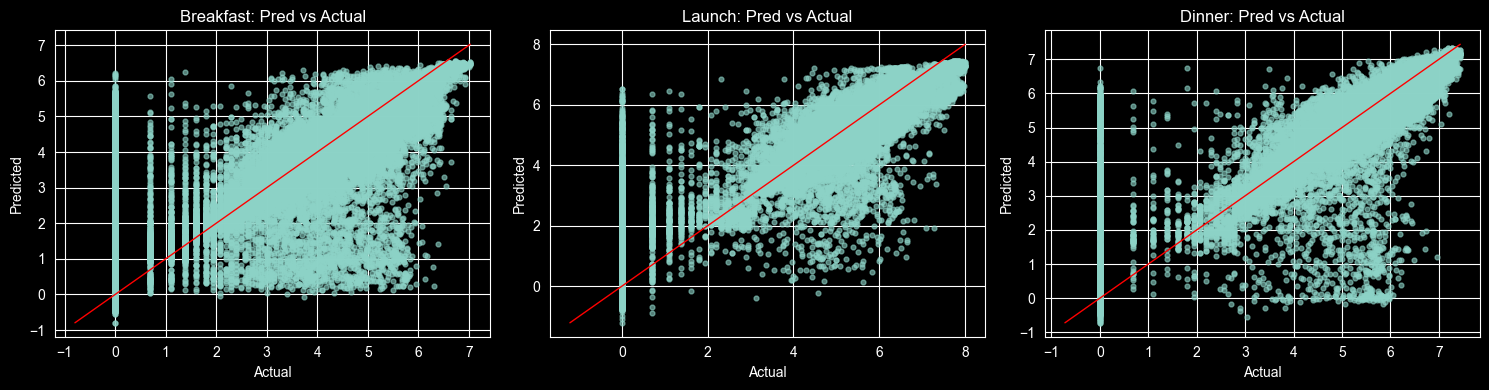

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(target_cols), figsize=(5 * len(target_cols), 4))
if len(target_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, target_cols):
    ax.scatter(y_test[col], preds[col], s=12, alpha=0.6)
    min_val = min(y_test[col].min(), preds[col].min())
    max_val = max(y_test[col].max(), preds[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1)
    ax.set_title(f"{col.title()}: Pred vs Actual")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()
